## **EDA of Drug Adverse Event Reporting Data**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

### **Data Loading**

In [4]:
reports = pd.read_csv("faers_2026q1_reports.csv",dtype=str,low_memory=False)
drugs = pd.read_csv("faers_2026q1_drugs.csv",dtype=str,low_memory=False)
reactions = pd.read_csv("faers_2026q1_reactions.csv",dtype=str,low_memory=False)

### **Data Validation**

##### **Reports structure,shapeand columns**

In [5]:
reports.head(2)

,source_file,safetyreportid,safetyreportversion,primarysourcecountry,occurcountry,transmissiondate,reporttype,serious,seriousnessdeath,seriousnesslifethreatening,...,patient_sex,patient_death_date,num_drugs,num_reactions,suspect_drugs,all_drugs,drug_indications,reactions,reaction_outcomes,serious_target
0,1_ADR26Q1.xml,24542592,6,JP,JP,20260424,2,1,2,2,...,1,NaN,19,3,FENFLURAMINE HYDROCHLORIDE,FENFLURAMINE HYDROCHLORIDE | DIACOMIT | DEPAKE...,Severe myoclonic epilepsy of infancy | Product...,Serotonin syndrome | Prescribed underdose | Of...,2 | 6,1
1,1_ADR26Q1.xml,26219463,1,US,US,20260415,1,NaN,NaN,NaN,...,NaN,NaN,1,2,XOFLUZA,XOFLUZA,Product used for unknown indication,Product prescribing error | No adverse event,6,0


In [6]:
reports.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397224 entries, 0 to 397223
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   source_file                   397224 non-null  object
 1   safetyreportid                397224 non-null  object
 2   safetyreportversion           397224 non-null  object
 3   primarysourcecountry          393386 non-null  object
 4   occurcountry                  365054 non-null  object
 5   transmissiondate              397224 non-null  object
 6   reporttype                    397123 non-null  object
 7   serious                       395691 non-null  object
 8   seriousnessdeath              390360 non-null  object
 9   seriousnesslifethreatening    389846 non-null  object
 10  seriousnesshospitalization    391001 non-null  object
 11  seriousnessdisabling          389720 non-null  object
 12  seriousnesscongenitalanomali  389540 non-null  object
 13 

In [7]:
reports.shape

(397224, 36)

In [8]:
reports.columns

Index(['source_file', 'safetyreportid', 'safetyreportversion',
       'primarysourcecountry', 'occurcountry', 'transmissiondate',
       'reporttype', 'serious', 'seriousnessdeath',
       'seriousnesslifethreatening', 'seriousnesshospitalization',
       'seriousnessdisabling', 'seriousnesscongenitalanomali',
       'seriousnessother', 'receivedate', 'receiptdate',
       'fulfillexpeditecriteria', 'companynumb', 'duplicate',
       'reportercountry', 'qualification', 'senderorganization', 'patient_age',
       'patient_age_unit', 'patient_age_years', 'patient_weight_kg',
       'patient_sex', 'patient_death_date', 'num_drugs', 'num_reactions',
       'suspect_drugs', 'all_drugs', 'drug_indications', 'reactions',
       'reaction_outcomes', 'serious_target'],
      dtype='object')

##### **Drugs Structure,Shape and Columns**

In [10]:
drugs.head(2)

,source_file,safetyreportid,drug_seq,drugcharacterization,medicinalproduct,drugauthorizationnumb,drugstructuredosagenumb,drugstructuredosageunit,drugdosagetext,drugadministrationroute,drugindication,drugstartdate,drugenddate,drugtreatmentduration,drugtreatmentdurationunit,actiondrug,activesubstancename
0,1_ADR26Q1.xml,24542592,1,1,FENFLURAMINE HYDROCHLORIDE,212102,.025,007,"0.025 MILLIGRAM/KILOGRAM, 2X/DAY (BID)",061,Severe myoclonic epilepsy of infancy,20240710,20240731,22,804,1,FENFLURAMINE HYDROCHLORIDE
1,1_ADR26Q1.xml,24542592,2,1,FENFLURAMINE HYDROCHLORIDE,212102,.05,007,"0.05 MILLIGRAM/KILOGRAM, 2X/DAY (BID)",061,NaN,20240801,20240903,34,804,1,FENFLURAMINE HYDROCHLORIDE


In [11]:
drugs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1897152 entries, 0 to 1897151
Data columns (total 17 columns):
 #   Column                     Dtype 
---  ------                     ----- 
 0   source_file                object
 1   safetyreportid             object
 2   drug_seq                   object
 3   drugcharacterization       object
 4   medicinalproduct           object
 5   drugauthorizationnumb      object
 6   drugstructuredosagenumb    object
 7   drugstructuredosageunit    object
 8   drugdosagetext             object
 9   drugadministrationroute    object
 10  drugindication             object
 11  drugstartdate              object
 12  drugenddate                object
 13  drugtreatmentduration      object
 14  drugtreatmentdurationunit  object
 15  actiondrug                 object
 16  activesubstancename        object
dtypes: object(17)
memory usage: 246.1+ MB


In [12]:
drugs.shape

(1897152, 17)

In [13]:
drugs.columns

Index(['source_file', 'safetyreportid', 'drug_seq', 'drugcharacterization',
       'medicinalproduct', 'drugauthorizationnumb', 'drugstructuredosagenumb',
       'drugstructuredosageunit', 'drugdosagetext', 'drugadministrationroute',
       'drugindication', 'drugstartdate', 'drugenddate',
       'drugtreatmentduration', 'drugtreatmentdurationunit', 'actiondrug',
       'activesubstancename'],
      dtype='object')

##### **Reactions Structure,Shape and Columns**

In [14]:
reactions.head(2)

,source_file,safetyreportid,reaction_seq,reactionmeddrapt,reactionoutcome
0,1_ADR26Q1.xml,24542592,1,Serotonin syndrome,2
1,1_ADR26Q1.xml,24542592,2,Prescribed underdose,6


In [15]:
reactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330675 entries, 0 to 1330674
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   source_file       1330675 non-null  object
 1   safetyreportid    1330675 non-null  object
 2   reaction_seq      1330675 non-null  object
 3   reactionmeddrapt  1330675 non-null  object
 4   reactionoutcome   1294496 non-null  object
dtypes: object(5)
memory usage: 50.8+ MB


In [16]:
reactions.shape

(1330675, 5)

In [17]:
reactions.columns

Index(['source_file', 'safetyreportid', 'reaction_seq', 'reactionmeddrapt',
       'reactionoutcome'],
      dtype='object')

##### **Missing Value Check**

In [18]:
reports.isnull().sum()

source_file                          0
safetyreportid                       0
safetyreportversion                  0
primarysourcecountry              3838
occurcountry                     32170
transmissiondate                     0
reporttype                         101
serious                           1533
seriousnessdeath                  6864
seriousnesslifethreatening        7378
seriousnesshospitalization        6223
seriousnessdisabling              7504
seriousnesscongenitalanomali      7684
seriousnessother                  4915
receivedate                          0
receiptdate                          0
fulfillexpeditecriteria              0
companynumb                      38748
duplicate                       327699
reportercountry                      4
qualification                     2153
senderorganization                   0
patient_age                     151608
patient_age_unit                151605
patient_age_years               151609
patient_weight_kg        

##### **Handling Missing Values**

In [19]:
# patient_death_date is 0/397224 non-null — no information at all
reports = reports.drop(columns=['patient_death_date'])


In [20]:
flag_cols = ['seriousnessdeath', 'seriousnesslifethreatening', 'seriousnesshospitalization',
             'seriousnessdisabling', 'seriousnesscongenitalanomali', 'seriousnessother',
             'fulfillexpeditecriteria', 'duplicate']
for col in flag_cols:
    reports[col] = pd.to_numeric(reports[col], errors='coerce').fillna(0).astype(int)

In [21]:
cat_fill_unknown = ['primarysourcecountry', 'occurcountry', 'reporttype', 'serious',
                     'qualification', 'reportercountry', 'companynumb', 'patient_sex']
for col in cat_fill_unknown:
    reports[col] = reports[col].fillna('UNKNOWN')

In [22]:
text_fill = ['suspect_drugs', 'drug_indications', 'reaction_outcomes']
for col in text_fill:
    reports[col] = reports[col].fillna('NOT SPECIFIED')

In [25]:
reports['patient_age'] = reports['patient_age'].fillna('UNKNOWN')
reports['patient_age_unit'] = reports['patient_age_unit'].fillna('UNKNOWN')

In [26]:
reports['patient_age_years'] = reports['patient_age_years'].fillna(-1)
reports['patient_weight_kg'] = reports['patient_weight_kg'].fillna(-1)

##### **Type Conversion**

In [23]:
reports['patient_age_years']  = pd.to_numeric(reports['patient_age_years'], errors='coerce')
reports['patient_weight_kg']  = pd.to_numeric(reports['patient_weight_kg'], errors='coerce')
reports['age_missing']    = reports['patient_age_years'].isna().astype(int)
reports['weight_missing'] = reports['patient_weight_kg'].isna().astype(int)

In [24]:
reports['num_drugs']      = pd.to_numeric(reports['num_drugs'], errors='coerce')
reports['num_reactions']  = pd.to_numeric(reports['num_reactions'], errors='coerce')

In [43]:
reports['patient_age_years']=pd.to_numeric(reports['patient_age_years'])

In [46]:
reports['patient_weight_kg'] = pd.to_numeric(reports['patient_weight_kg'])

In [49]:
reports['num_drugs']=pd.to_numeric(reports['num_drugs'])

In [52]:
reports['num_reactions']=pd.to_numeric(reports['num_reactions'])

In [27]:
reports.isnull().sum()

source_file                     0
safetyreportid                  0
safetyreportversion             0
primarysourcecountry            0
occurcountry                    0
transmissiondate                0
reporttype                      0
serious                         0
seriousnessdeath                0
seriousnesslifethreatening      0
seriousnesshospitalization      0
seriousnessdisabling            0
seriousnesscongenitalanomali    0
seriousnessother                0
receivedate                     0
receiptdate                     0
fulfillexpeditecriteria         0
companynumb                     0
duplicate                       0
reportercountry                 0
qualification                   0
senderorganization              0
patient_age                     0
patient_age_unit                0
patient_age_years               0
patient_weight_kg               0
patient_sex                     0
num_drugs                       0
num_reactions                   0
suspect_drugs 

In [28]:
drugs.isnull().sum()

source_file                        0
safetyreportid                     0
drug_seq                           0
drugcharacterization               0
medicinalproduct                   6
drugauthorizationnumb        1253385
drugstructuredosagenumb      1101708
drugstructuredosageunit      1102285
drugdosagetext                539277
drugadministrationroute      1000187
drugindication                757212
drugstartdate                1531945
drugenddate                  1719225
drugtreatmentduration        1746584
drugtreatmentdurationunit    1746584
actiondrug                    530931
activesubstancename            36483
dtype: int64

In [29]:
for col in ['drugindication', 'drugauthorizationnumb']:
    if col in drugs.columns:
        drugs[col] = drugs[col].fillna('NOT SPECIFIED')

In [30]:
drugs.isnull().sum()

source_file                        0
safetyreportid                     0
drug_seq                           0
drugcharacterization               0
medicinalproduct                   6
drugauthorizationnumb              0
drugstructuredosagenumb      1101708
drugstructuredosageunit      1102285
drugdosagetext                539277
drugadministrationroute      1000187
drugindication                     0
drugstartdate                1531945
drugenddate                  1719225
drugtreatmentduration        1746584
drugtreatmentdurationunit    1746584
actiondrug                    530931
activesubstancename            36483
dtype: int64

In [31]:
reactions.isnull().sum()

source_file             0
safetyreportid          0
reaction_seq            0
reactionmeddrapt        0
reactionoutcome     36179
dtype: int64

##### **Identifying Duplicates**

In [32]:
reports['safetyreportid'].duplicated().sum()

np.int64(0)

In [33]:
drugs['safetyreportid'].duplicated().sum()

np.int64(1499928)

In [34]:
reactions['safetyreportid'].duplicated().sum()

np.int64(933451)

In [35]:
print("Exact duplicate rows — reports:", reports.duplicated().sum())
print("Exact duplicate rows — drugs:", drugs.duplicated().sum())
print("Exact duplicate rows — reactions:", reactions.duplicated().sum())

Exact duplicate rows — reports: 0
Exact duplicate rows — drugs: 0
Exact duplicate rows — reactions: 0


### **UnivariateAnalysis**

##### **Analysis of patient_sex column data**

In [36]:
reports['patient_sex'].value_counts()

patient_sex
2          198072
1          123719
UNKNOWN     75433
Name: count, dtype: int64

In [37]:
reports['patient_sex'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 397224 entries, 0 to 397223
Series name: patient_sex
Non-Null Count   Dtype 
--------------   ----- 
397224 non-null  object
dtypes: object(1)
memory usage: 3.0+ MB


##### **Analysis of reporttype column data**

In [38]:
reports['reporttype'].value_counts()

reporttype
1          308393
2           84899
3            3831
UNKNOWN       101
Name: count, dtype: int64

##### **Analysis of qualification column data**

In [39]:
reports['qualification'].value_counts()

qualification
5          197369
3           97551
1           76890
2           19522
4            3739
UNKNOWN      2153
Name: count, dtype: int64

##### **Analysis of occurcountry column data**

In [40]:
reports['occurcountry'].value_counts()

occurcountry
US         242036
EU          40509
UNKNOWN     32170
CA          20499
GB          15536
            ...  
KP              1
AW              1
SL              1
AG              1
MO              1
Name: count, Length: 139, dtype: int64

##### **Analysis of primarysourcecountry data**

In [41]:
reports['primarysourcecountry'].value_counts()

primarysourcecountry
US    268765
EU     40776
CA     19965
GB     15916
JP     15280
       ...  
AW         1
SX         1
AG         1
PG         1
TG         1
Name: count, Length: 135, dtype: int64

##### **Individual categorical distribution plots of patient_sex and reporttype data**

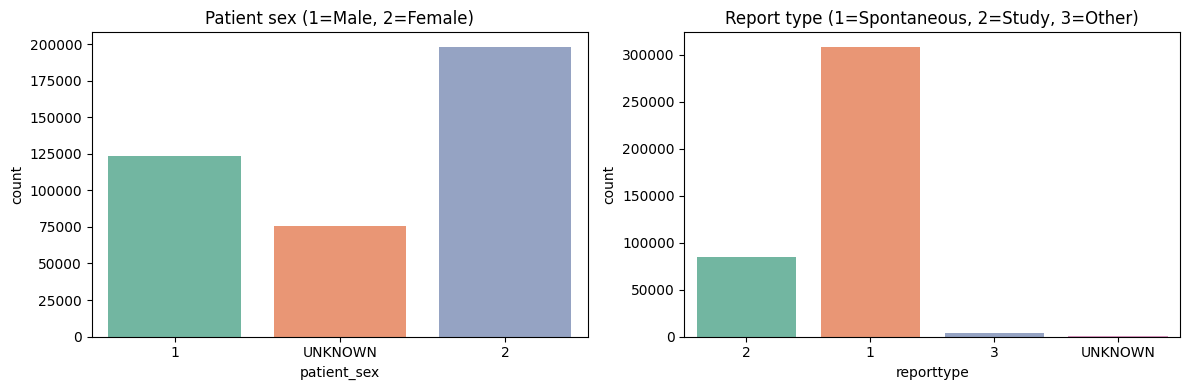

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=reports, x='patient_sex', hue='patient_sex', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Patient sex (1=Male, 2=Female)')

sns.countplot(data=reports, x='reporttype', hue='reporttype', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Report type (1=Spontaneous, 2=Study, 3=Other)')
plt.tight_layout()
plt.show()

##### **Analysis of patient_age_years data**

In [44]:
reports['patient_age_years'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 397224 entries, 0 to 397223
Series name: patient_age_years
Non-Null Count   Dtype  
--------------   -----  
397224 non-null  float64
dtypes: float64(1)
memory usage: 3.0 MB


In [45]:
reports['patient_age_years'].describe()

count    397224.000000
mean         33.634293
std          31.925222
min          -1.000000
25%          -1.000000
50%          35.000000
75%          64.000000
max         700.000000
Name: patient_age_years, dtype: float64

##### **Analysis of patient_weight_kg data**

In [47]:
reports['patient_weight_kg'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 397224 entries, 0 to 397223
Series name: patient_weight_kg
Non-Null Count   Dtype  
--------------   -----  
397224 non-null  float64
dtypes: float64(1)
memory usage: 3.0 MB


In [48]:
reports['patient_weight_kg'].describe()

count    397224.000000
mean         12.326719
std         138.199260
min          -1.000000
25%          -1.000000
50%          -1.000000
75%          -1.000000
max       80505.000000
Name: patient_weight_kg, dtype: float64

##### **Analysis of num_drugs data**

In [50]:
reports['num_drugs'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 397224 entries, 0 to 397223
Series name: num_drugs
Non-Null Count   Dtype
--------------   -----
397224 non-null  int64
dtypes: int64(1)
memory usage: 3.0 MB


In [51]:
reports['num_drugs'].describe()

count    397224.000000
mean          4.776026
std          22.690986
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        3037.000000
Name: num_drugs, dtype: float64

##### **Analysis of num_reactions data**

In [53]:
reports['num_reactions'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 397224 entries, 0 to 397223
Series name: num_reactions
Non-Null Count   Dtype
--------------   -----
397224 non-null  int64
dtypes: int64(1)
memory usage: 3.0 MB


In [54]:
reports['num_reactions'].describe()

count    397224.000000
mean          3.349936
std           5.419363
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         236.000000
Name: num_reactions, dtype: float64

##### **Distribution plots of patient_age_years, patient_weight_kg, num_drugs, num_reactions**

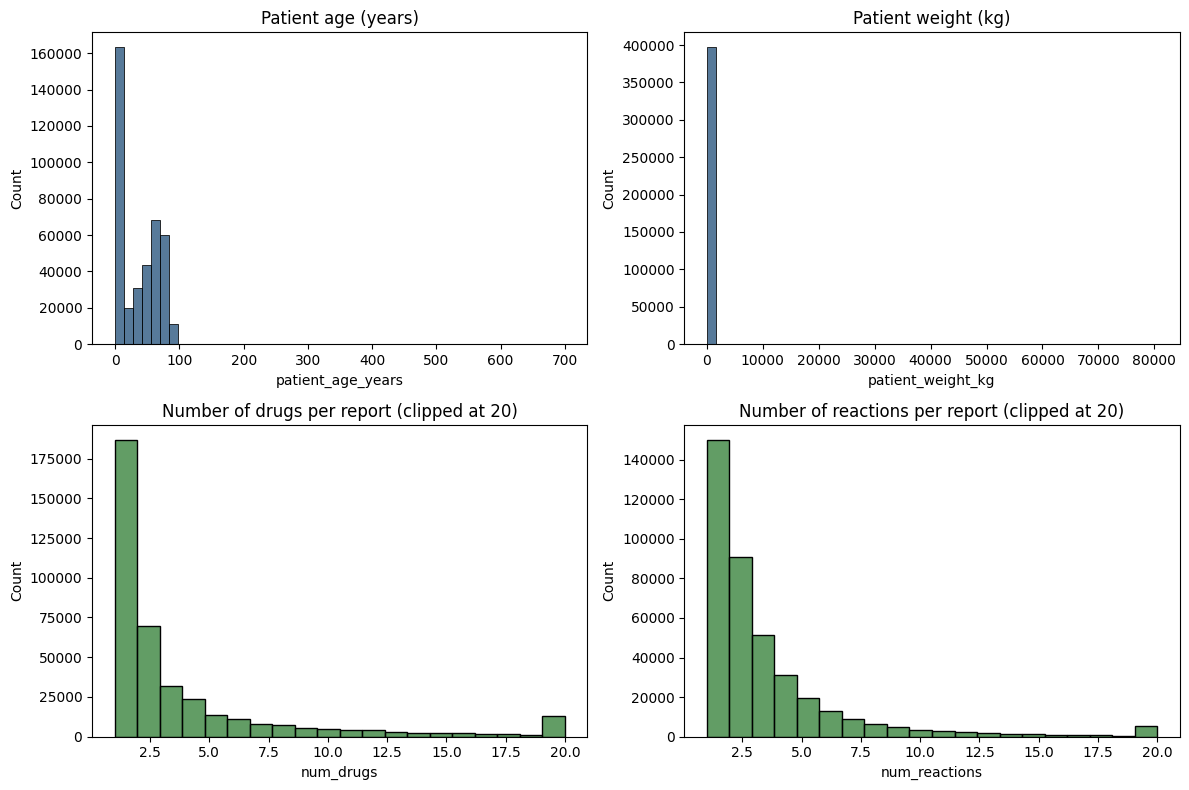

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(reports['patient_age_years'].dropna(), bins=50, ax=axes[0, 0], color='#1F4E78')
axes[0, 0].set_title('Patient age (years)')

sns.histplot(reports['patient_weight_kg'].dropna(), bins=50, ax=axes[0, 1], color='#1F4E78')
axes[0, 1].set_title('Patient weight (kg)')

sns.histplot(reports['num_drugs'].clip(upper=20), bins=20, ax=axes[1, 0], color='#2E7D32')
axes[1, 0].set_title('Number of drugs per report (clipped at 20)')

sns.histplot(reports['num_reactions'].clip(upper=20), bins=20, ax=axes[1, 1], color='#2E7D32')
axes[1, 1].set_title('Number of reactions per report (clipped at 20)')
plt.tight_layout()
plt.show()

In [56]:
print("Ages > 120 years:", (reports['patient_age_years'] > 120).sum())
print(reports.loc[reports['patient_age_years'] > 120, ['safetyreportid', 'patient_age', 'patient_age_unit', 'patient_age_years']].head())
print()
print("Weights > 300 kg:", (reports['patient_weight_kg'] > 300).sum())
print(reports.loc[reports['patient_weight_kg'] > 300, ['safetyreportid', 'patient_weight_kg']].head())
print()
print("num_drugs > 50 (likely combination-product or data entry outliers):", (reports['num_drugs'] > 50).sum())

Ages > 120 years: 4
       safetyreportid patient_age patient_age_unit  patient_age_years
58509        26274004          23              800              230.0
194669       26389941         126              801              126.0
330713       26506533          40              800              400.0
332858       26508341          70              800              700.0

Weights > 300 kg: 21
       safetyreportid  patient_weight_kg
19007        26236857             320.00
55276        26257704             413.00
60758        14857330             330.70
67421        26278818             413.00
104092       24876225             551.15

num_drugs > 50 (likely combination-product or data entry outliers): 2479


##### **Boxplot or Outlier of Patient age and weight**

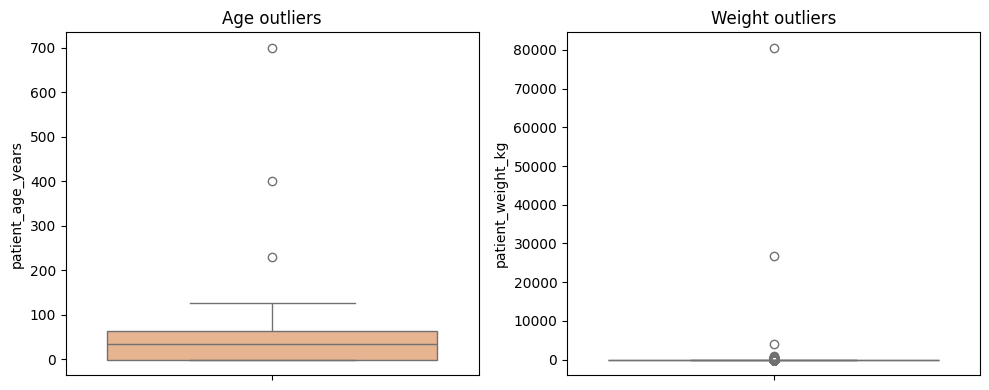

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=reports['patient_age_years'], ax=axes[0], color='#F4B183')
axes[0].set_title('Age outliers')
sns.boxplot(y=reports['patient_weight_kg'], ax=axes[1], color='#F4B183')
axes[1].set_title('Weight outliers')

plt.tight_layout()
plt.show()

In [58]:
print("Weights > 300 kg:", (reports['patient_weight_kg'] > 300).sum())
print(reports.loc[reports['patient_weight_kg'] > 300, ['safetyreportid', 'patient_weight_kg']])
print()

Weights > 300 kg: 21
       safetyreportid  patient_weight_kg
19007        26236857             320.00
55276        26257704             413.00
60758        14857330             330.70
67421        26278818             413.00
104092       24876225             551.15
104375       26312820            4105.00
125060       25649013             315.00
128796       25666281             337.00
142079       25635151             345.00
158208       25688526             324.00
186009       26382257           80505.00
186514       26382730           26775.00
202711       25647714             310.00
202822       26394771             310.00
221441       26412047             340.00
287620       26468703             485.00
321785       26465577             335.00
322605       25487378             384.00
323513       26500176             849.00
342349       25408494             330.00
364791       26535387             349.72



##### **Outlier Detection Using the IQR Method**

In [59]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

for col in ['patient_age_years', 'patient_weight_kg', 'num_drugs', 'num_reactions']:
    lo, hi = iqr_bounds(reports[col].dropna())
    reports[f'{col}_iqr_outlier'] = ((reports[col] < lo) | (reports[col] > hi)).astype(int)
    print(f"{col}: IQR bounds ({lo:.1f}, {hi:.1f}), outliers = {reports[f'{col}_iqr_outlier'].sum()}")

patient_age_years: IQR bounds (-98.5, 161.5), outliers = 3
patient_weight_kg: IQR bounds (-1.0, -1.0), outliers = 69091
num_drugs: IQR bounds (-3.5, 8.5), outliers = 45563
num_reactions: IQR bounds (-3.5, 8.5), outliers = 25356


In [60]:
reports.loc[reports['patient_age_years'] > 120, 'patient_age_years'] = np.nan
reports.loc[reports['patient_age_years'] < 0,   'patient_age_years'] = np.nan
reports.loc[reports['patient_weight_kg'] > 300, 'patient_weight_kg'] = np.nan
reports.loc[reports['patient_weight_kg'] <= 0,  'patient_weight_kg'] = np.nan

### **Bivariate Analysis**

##### **Analysis of Age statistics by reporttype**

In [61]:
reports.groupby('reporttype')['patient_age_years'].describe()

,count,mean,std,min,25%,50%,75%,max
reporttype,,,,,,,,
1,190408.0,54.749822,21.201264,0.0,41.0,59.0,71.0,105.0
2,53481.0,56.070027,21.073472,0.0,43.0,61.0,72.0,114.0
3,1656.0,50.155883,20.587728,0.0,36.0,52.0,66.0,97.0
UNKNOWN,66.0,59.969697,17.242140,16.0,54.0,66.5,71.0,83.0


##### **Age by Reporter Qualification**

In [62]:
reports.groupby('qualification')['patient_age_years'].describe()

,count,mean,std,min,25%,50%,75%,max
qualification,,,,,,,,
1,53530.0,55.492322,21.530281,0.0,41.0,60.0,72.0,105.0
2,13317.0,58.481164,21.332594,0.0,45.0,63.0,75.0,114.0
3,68102.0,51.156437,22.039122,0.0,36.0,55.0,69.0,104.0
4,1434.0,48.773361,15.139116,0.0,39.0,50.0,59.0,88.0
5,107817.0,56.794081,20.110444,0.0,44.0,61.0,72.0,114.0
UNKNOWN,1411.0,59.560296,21.875374,0.0,49.0,65.0,75.0,100.0


##### **Age by Patient sex**

In [63]:
reports.groupby('patient_sex')['patient_age_years'].describe()

,count,mean,std,min,25%,50%,75%,max
patient_sex,,,,,,,,
1,89863.0,55.923008,22.313502,0.0,43.0,62.0,73.0,103.0
2,136003.0,54.956559,20.283899,0.0,41.0,59.0,70.0,114.0
UNKNOWN,19745.0,51.194488,21.481076,0.0,36.0,54.0,68.0,114.0


##### **Report type by Number of drugs**

In [64]:
reports.groupby('reporttype')['num_drugs'].describe()

,count,mean,std,min,25%,50%,75%,max
reporttype,,,,,,,,
1,308393.0,4.736165,23.818218,1.0,1.0,2.0,4.0,2664.0
2,84899.0,4.694213,10.889907,1.0,1.0,2.0,5.0,1531.0
3,3831.0,9.821979,71.172711,1.0,1.0,2.0,5.0,3037.0
UNKNOWN,101.0,3.861386,4.005071,1.0,1.0,2.0,5.0,21.0


##### **Number of reactions by sex**

In [65]:
reports.groupby('patient_sex')['num_reactions'].describe()

,count,mean,std,min,25%,50%,75%,max
patient_sex,,,,,,,,
1,123719.0,3.076746,3.905649,1.0,1.0,2.0,4.0,142.0
2,198072.0,3.674578,6.347282,1.0,1.0,2.0,4.0,236.0
UNKNOWN,75433.0,2.945554,4.825829,1.0,1.0,2.0,3.0,200.0


##### **Seriousness rate by Patient sex**

In [66]:
reports['serious'] = pd.to_numeric(reports['serious'], errors='coerce')

In [67]:
reports.groupby('patient_sex')['serious'].mean()

patient_sex
1          1.357533
2          1.467628
UNKNOWN    1.549779
Name: serious, dtype: float64

##### **Seriousness rate by country**

In [68]:
reports.groupby('occurcountry')['serious'].mean()

occurcountry
A1    1.571429
AE    1.077670
AF    1.000000
AG    1.000000
AI    1.000000
        ...   
VE    1.000000
VN    1.023669
ZA    1.010989
ZM    1.000000
ZW    1.000000
Name: serious, Length: 139, dtype: float64

##### **Seriousness rate by qualification**

In [69]:
reports.groupby('qualification')['serious'].mean()

qualification
1          1.223595
2          1.305944
3          1.421892
4          1.068316
5          1.572824
UNKNOWN    1.359498
Name: serious, dtype: float64

##### **Boxplot: Patient Age by Report Type**

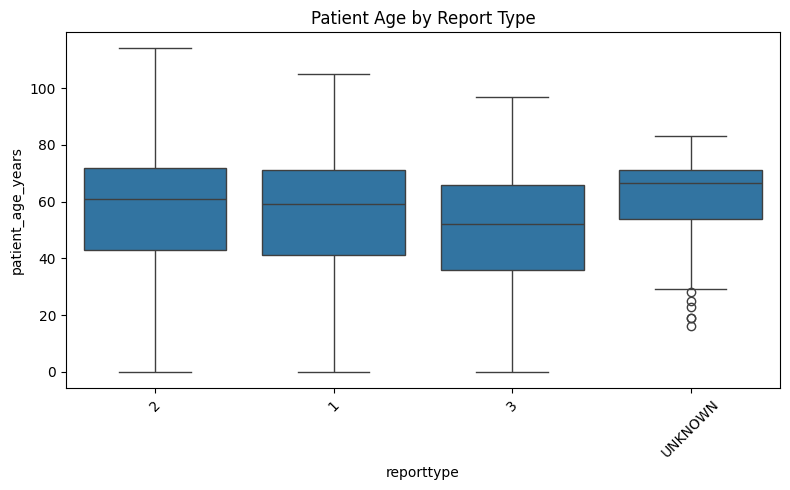

In [70]:
age_data = reports[reports['patient_age_years'] <= 120]

plt.figure(figsize=(8, 5))
sns.boxplot(data=age_data, x='reporttype', y='patient_age_years')
plt.title('Patient Age by Report Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### **Boxplot: Number of Drugs by Sex**

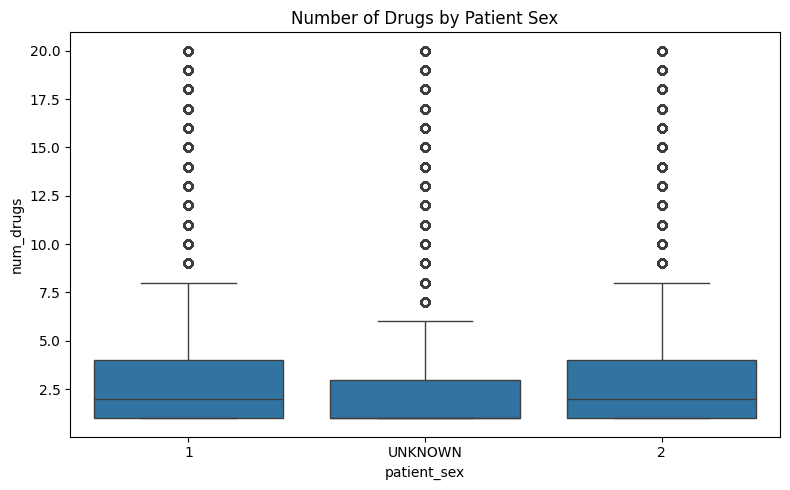

In [71]:
drugs_data = reports[reports['num_drugs'] <= 20]

plt.figure(figsize=(8, 5))
sns.boxplot(data=drugs_data, x='patient_sex', y='num_drugs')
plt.title('Number of Drugs by Patient Sex')
plt.tight_layout()
plt.show()

##### **Boxplot: Reactions by Qualification**

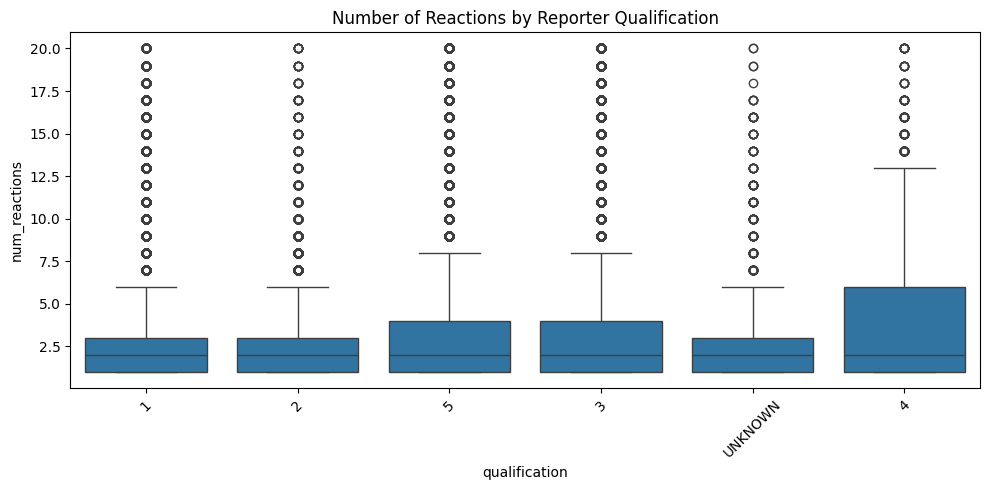

In [72]:
reactions_data = reports[reports['num_reactions'] <= 20]

plt.figure(figsize=(10, 5))
sns.boxplot(data=reactions_data, x='qualification', y='num_reactions')
plt.title('Number of Reactions by Reporter Qualification')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### **Scatter plot of number of reactions**

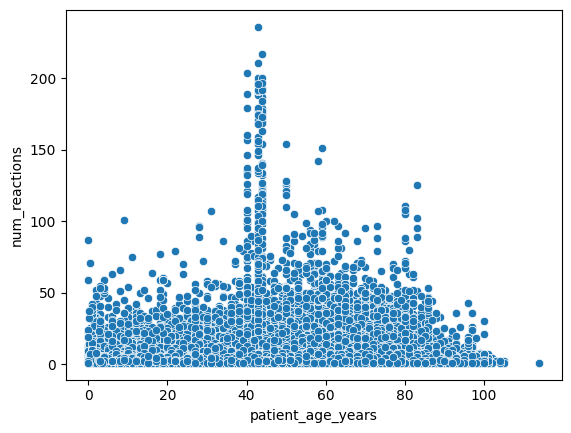

In [73]:
sns.scatterplot(x='patient_age_years',y='num_reactions',data=reports)
plt.show()

##### **Scatter plot of number of drugs**

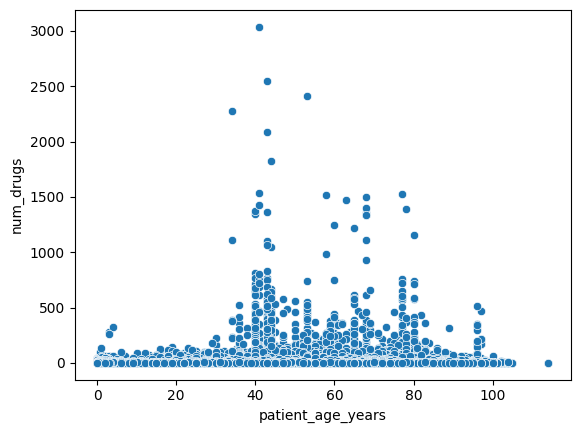

In [74]:
sns.scatterplot(x='patient_age_years',y='num_drugs',data=reports)
plt.show()

##### **Scatter plot of num_drugs vs num_reactions**

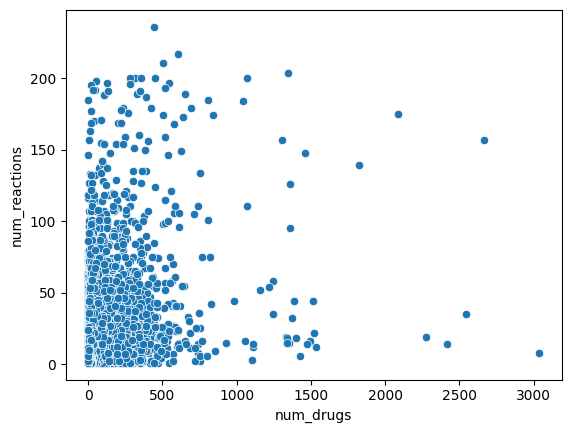

In [75]:
sns.scatterplot(x='num_drugs',y='num_reactions',data=reports)
plt.show()

##### **Scatter plot of patient weight vs number of drugs**

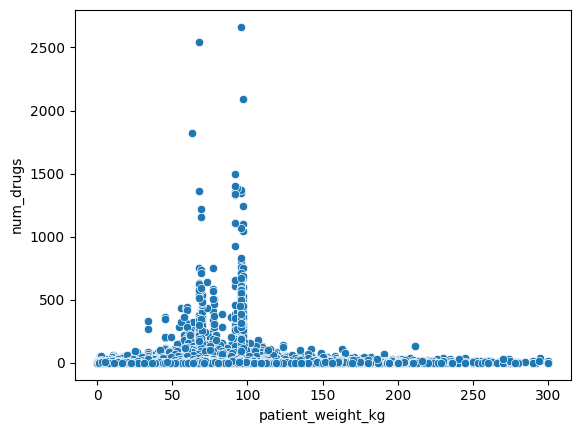

In [76]:
sns.scatterplot(x='patient_weight_kg',y='num_drugs',data=reports)
plt.show()

### **Multivariate Analysis**

##### **Correlation Analysis of Numerical Variables and Seriousness**

In [84]:
cols = ['serious', 'seriousnessdeath', 'seriousnesslifethreatening',
    'seriousnesshospitalization', 'seriousnessdisabling',
    'seriousnesscongenitalanomali', 'seriousnessother',
    'fulfillexpeditecriteria', 'duplicate',
    'patient_age_years', 'patient_weight_kg',
    'num_drugs', 'num_reactions', 'serious_target']
reports[cols].corr(numeric_only = True)

,serious,seriousnessdeath,seriousnesslifethreatening,seriousnesshospitalization,seriousnessdisabling,seriousnesscongenitalanomali,seriousnessother,fulfillexpeditecriteria,duplicate,patient_age_years,patient_weight_kg,num_drugs,num_reactions
serious,1.000000,0.206603,0.113652,0.407847,0.065592,0.033369,0.692940,0.664203,-0.210054,-0.079587,0.052213,-0.083965,-0.157856
seriousnessdeath,0.206603,1.000000,0.584669,0.345649,0.627046,0.667489,0.264012,0.131276,-0.001684,-0.082539,0.008011,-0.052858,-0.028070
seriousnesslifethreatening,0.113652,0.584669,1.000000,0.501098,0.793302,0.824650,0.316844,0.066188,-0.055593,0.002088,-0.001947,-0.075655,-0.085129
seriousnesshospitalization,0.407847,0.345649,0.501098,1.000000,0.463128,0.479217,0.213380,0.238630,-0.101931,-0.058983,0.035060,-0.082232,-0.134924
seriousnessdisabling,0.065592,0.627046,0.793302,0.463128,1.000000,0.909865,0.323344,0.022798,-0.016226,-0.007209,-0.025216,-0.071429,-0.086771
seriousnesscongenitalanomali,0.033369,0.667489,0.824650,0.479217,0.909865,1.000000,0.326613,0.009728,0.001184,-0.006190,0.000380,-0.047244,-0.046632
seriousnessother,0.692940,0.264012,0.316844,0.213380,0.323344,0.326613,1.000000,0.494373,-0.142188,-0.008913,0.007957,-0.080288,-0.171475
fulfillexpeditecriteria,0.664203,0.131276,0.066188,0.238630,0.022798,0.009728,0.494373,1.000000,-0.194105,-0.078019,0.053906,-0.073919,-0.131533
duplicate,-0.210054,-0.001684,-0.055593,-0.101931,-0.016226,0.001184,-0.142188,-0.194105,1.000000,0.008798,-0.059858,0.099259,0.088579
patient_age_years,-0.079587,-0.082539,0.002088,-0.058983,-0.007209,-0.006190,-0.008913,-0.078019,0.008798,1.000000,0.193182,0.004307,-0.030103


##### **Correlation Heatmap of Seriousness and Numerical Variables**

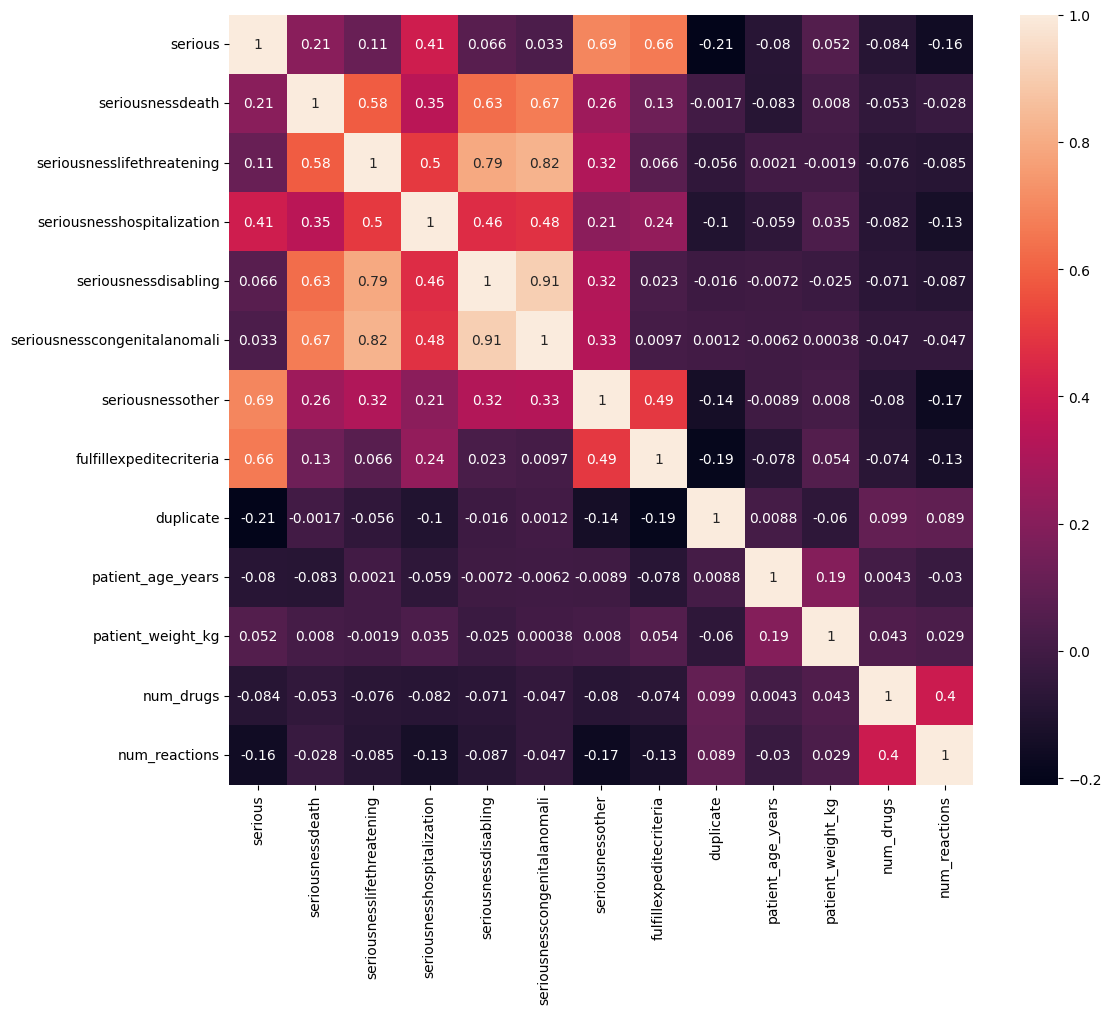

In [78]:
cols = ['serious', 'seriousnessdeath', 'seriousnesslifethreatening',
    'seriousnesshospitalization', 'seriousnessdisabling',
    'seriousnesscongenitalanomali', 'seriousnessother',
    'fulfillexpeditecriteria', 'duplicate',
    'patient_age_years', 'patient_weight_kg',
    'num_drugs', 'num_reactions', 'serious_target']

plt.figure(figsize=(12, 10))
sns.heatmap(reports[cols].corr(numeric_only = True),annot=True)
plt.show()

##### **Pairplot of Age,Weight,Drugs,Reactions,Serious Target and Sex**

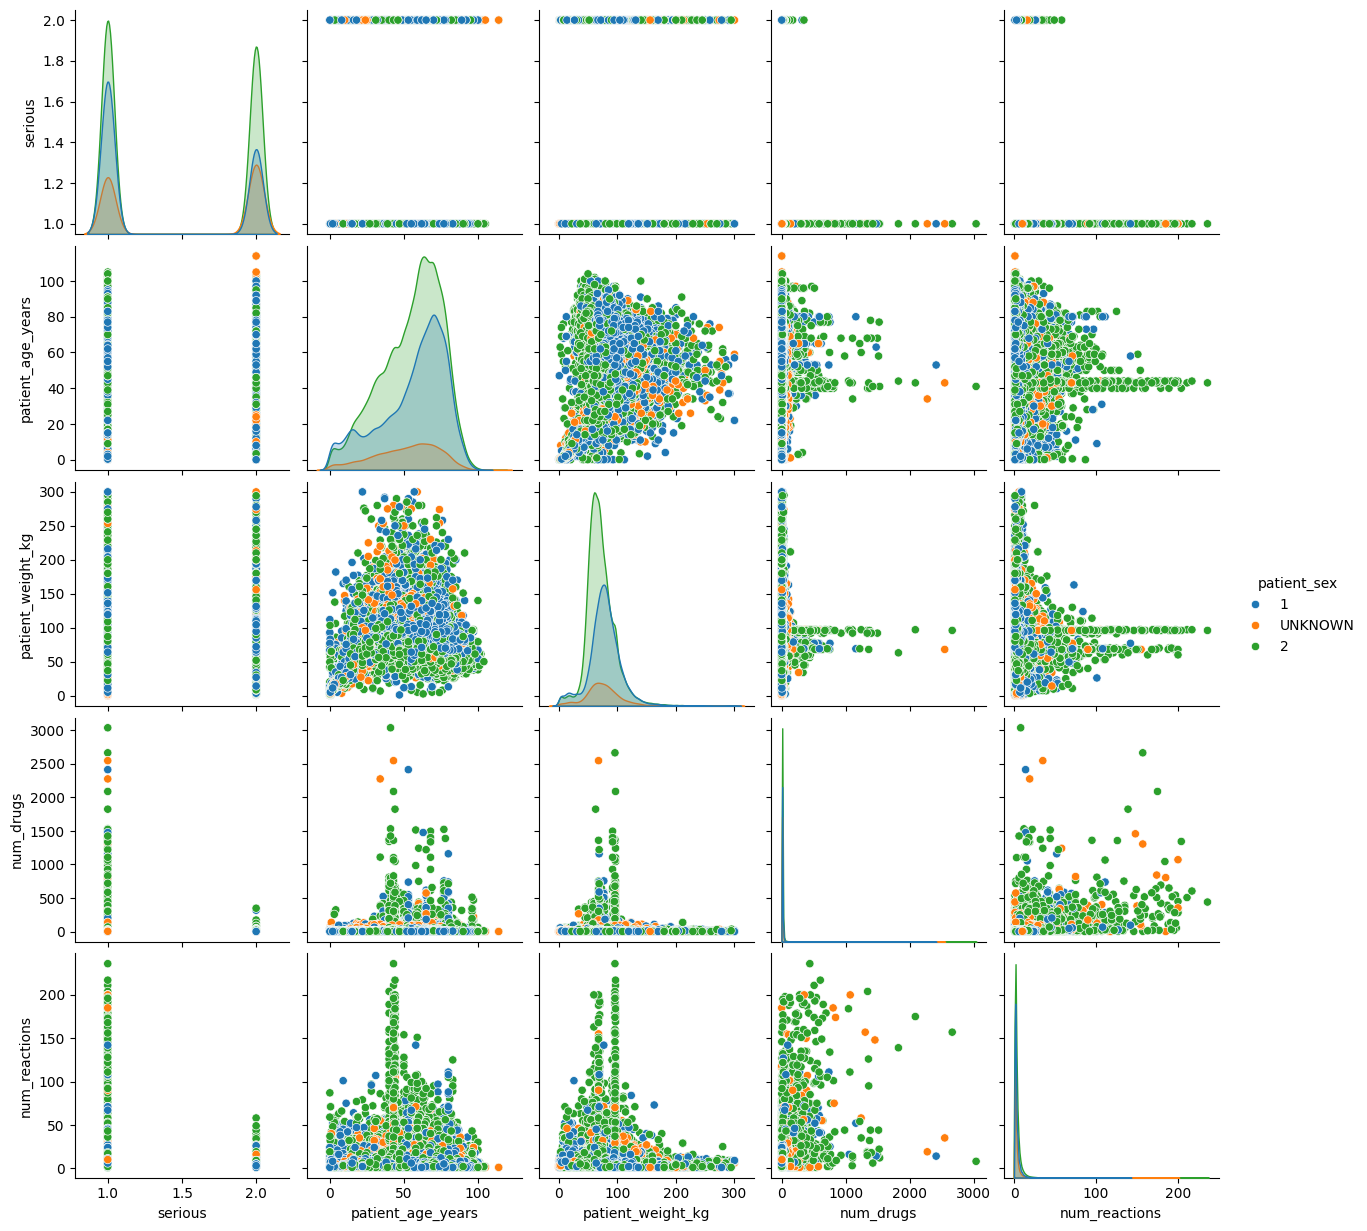

In [79]:
cols1 = ['serious','patient_age_years', 'patient_weight_kg',
    'num_drugs', 'num_reactions', 'serious_target','patient_sex']

sns.pairplot(reports[cols1],hue='patient_sex')
plt.show()

##### **MUtlivariable Correlation Analysis of Patient,drug,reaction and seriousness variables**

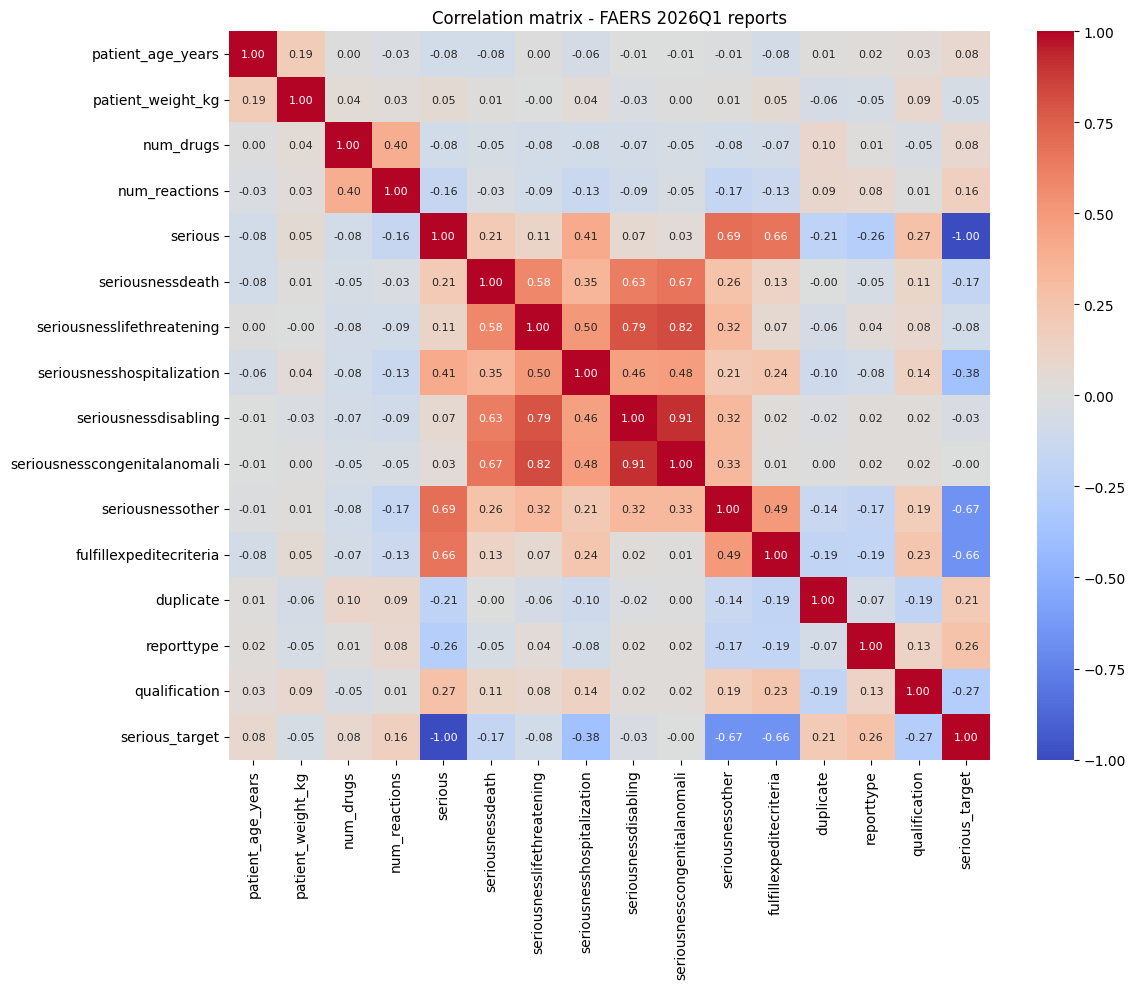

In [81]:
cols = ['patient_age_years', 'patient_weight_kg', 'num_drugs', 'num_reactions',
        'serious', 'seriousnessdeath', 'seriousnesslifethreatening', 'seriousnesshospitalization',
        'seriousnessdisabling', 'seriousnesscongenitalanomali', 'seriousnessother',
        'fulfillexpeditecriteria', 'duplicate', 'reporttype', 'qualification', 'serious_target']

corr_df = reports[cols].copy()
for c in corr_df.columns:
    corr_df[c] = pd.to_numeric(corr_df[c], errors='coerce')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', annot_kws={"size": 8})
plt.title('Correlation matrix - FAERS 2026Q1 reports')
plt.tight_layout()
plt.show()

##### **Export Cleaned Data**

In [82]:
reports.to_csv("faers_2026q1_reports_cleaned.csv", index=False)
drugs.to_csv("faers_2026q1_drugs_cleaned.csv", index=False)
reactions.to_csv("faers_2026q1_reactions_cleaned.csv", index=False)

### Insights

- The dataset contains 397,224 adverse-event reports, covering different patient groups, report types, reporter qualifications, and countries.
- Most of the reports are of Type 1 nearly 308393 reports while Type and Type 3 occur less frequently.
- Most adverse are reported from United States making it as the largest contributer to the dataset.
- Maximum patients are middle aged and older typically around 50 to 60 years but there are few unrealistic values above 120 years up to 700 indicating possible data entry or age unit conversion issues.
- Patient weight contains many missing/default values and some extreme values above 300 kg, including values as high as 80,505 kg.
- Most of the reports have small no of drugs nad reactions (median is 2 drugs and 2 drugs ) only few reports contains extremely high counts .Some reports contain more than 50 drugs and a maximum of 3037 .These extreme values may represent complex reports or data quality issue.
- The number of reactions has a right-skewed distribution with most reports containing only a few reactions, while few reports have a very large number with a maximum of 236 reactions.
- Patient age varies slightly across report types and reporter qualifications but the differences are relatively small.
- As per the correlation analysis shows that patient age, patient weight, number of drugs, and number of reactions have relatively weak relationships with seriousness.so these alone may not be enough to predict whether an adverse-event report is serious.
- Seriousness-related variables such as hospitalization, death, life-threatening events, disability, and other serious outcomes show stronger relationships with overall seriousness than the basic patient characteristics.
- As per EDA patient information, drug information, reaction information, reporter information, and seriousness indicators together may be useful for understanding adverse-event severity.